In [1]:
import pandas as pd
import numpy as np
import pyarrow as pa
import pyarrow.ipc as ipc

import time
import io

import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
BASE_DIR = Path.cwd().parent

RESULTS_DIR = (
    BASE_DIR /
    "results" /
    "nested_array_effects"
)

GRAPHS_DIR = RESULTS_DIR / "graphs"
TABLES_DIR = RESULTS_DIR / "tables"
LOGS_DIR = RESULTS_DIR / "logs"

GRAPHS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TABLES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

LOGS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(f"Results directory: {RESULTS_DIR}")

Results directory: /home/megh/arrow-ipc-analysis-linux/results/nested_array_effects


In [3]:
print("\n" + "="*80)
print("ARROW IPC NESTED ARRAY EFFECTS")
print("="*80)

print("""
Goal:
Study how nested Arrow arrays affect IPC serialization.

This experiment compares:

1. Primitive arrays
2. List arrays
3. Struct arrays
4. Deeply nested arrays

The experiment measures:

- Serialization time
- Deserialization time
- Payload size
- Schema complexity
- Buffer behavior

Your modified writer.cc instrumentation
will automatically expose:

- Field node growth
- Body buffer growth
- Nested traversal behavior
- Serialization overhead
""")


ARROW IPC NESTED ARRAY EFFECTS

Goal:
Study how nested Arrow arrays affect IPC serialization.

This experiment compares:

1. Primitive arrays
2. List arrays
3. Struct arrays
4. Deeply nested arrays

The experiment measures:

- Serialization time
- Deserialization time
- Payload size
- Schema complexity
- Buffer behavior

Your modified writer.cc instrumentation
will automatically expose:

- Field node growth
- Body buffer growth
- Nested traversal behavior
- Serialization overhead



In [4]:
N = 200_000

print(f"\nRows: {N:,}")


Rows: 200,000


In [5]:
print("\nCreating primitive table...")

primitive_table = pa.table({
    "id": np.arange(N),
    "value": np.random.randn(N)
})

print(primitive_table.schema)


Creating primitive table...
id: int64
value: double


In [6]:
print("\nCreating list array table...")

list_data = [
    [i, i + 1, i + 2]
    for i in range(N)
]

list_array = pa.array(
    list_data,
    type=pa.list_(pa.int64())
)

list_table = pa.table({
    "nested_list": list_array
})

print(list_table.schema)


Creating list array table...
nested_list: list<item: int64>
  child 0, item: int64


In [7]:
print("\nCreating struct array table...")

struct_array = pa.array([
    {
        "x": i,
        "y": float(i) * 0.5
    }
    for i in range(N)
])

struct_table = pa.table({
    "struct_col": struct_array
})

print(struct_table.schema)


Creating struct array table...
struct_col: struct<x: int64, y: double>
  child 0, x: int64
  child 1, y: double


In [8]:
print("\nCreating deeply nested table...")

deep_nested = pa.array([
    {
        "id": i,
        "values": [
            {
                "a": i,
                "b": i * 2
            },
            {
                "a": i + 1,
                "b": i * 3
            }
        ]
    }
    for i in range(N)
])

deep_table = pa.table({
    "deep_nested": deep_nested
})

print(deep_table.schema)


Creating deeply nested table...
deep_nested: struct<id: int64, values: list<item: struct<a: int64, b: int64>>>
  child 0, id: int64
  child 1, values: list<item: struct<a: int64, b: int64>>
      child 0, item: struct<a: int64, b: int64>
          child 0, a: int64
          child 1, b: int64


In [9]:
tables = [
    ("Primitive", primitive_table),
    ("List", list_table),
    ("Struct", struct_table),
    ("DeepNested", deep_table)
]

In [10]:
def benchmark_table(name, table):

    # ------------------------------------------
    # Serialize
    # ------------------------------------------

    sink = io.BytesIO()

    start = time.perf_counter()

    writer = ipc.new_stream(
        sink,
        table.schema
    )

    writer.write_table(table)

    writer.close()

    serialization_time = (
        time.perf_counter() - start
    )

    serialized_data = sink.getvalue()

    payload_size_mb = (
        len(serialized_data) /
        (1024 ** 2)
    )

    # ------------------------------------------
    # Deserialize
    # ------------------------------------------

    start = time.perf_counter()

    reader = ipc.open_stream(
        serialized_data
    )

    recovered = reader.read_all()

    deserialization_time = (
        time.perf_counter() - start
    )

    # ------------------------------------------
    # Schema Complexity
    # ------------------------------------------

    schema_string = str(table.schema)

    schema_depth = (
        schema_string.count("list") +
        schema_string.count("struct")
    )

    return {
        "Structure": name,

        "Serialization_Time_s":
            serialization_time,

        "Deserialization_Time_s":
            deserialization_time,

        "Payload_Size_MB":
            payload_size_mb,

        "Schema_Depth":
            schema_depth,

        "Columns":
            table.num_columns,

        "Rows":
            table.num_rows
    }

In [11]:
print("\n" + "="*80)
print("RUNNING NESTED ARRAY EXPERIMENTS")
print("="*80)

results = []

for name, table in tables:

    print("\n" + "-"*80)
    print(f"Testing: {name}")
    print("-"*80)

    result = benchmark_table(
        name,
        table
    )

    results.append(result)

    print(
        f"Serialization Time : "
        f"{result['Serialization_Time_s']:.6f}s"
    )

    print(
        f"Deserialization Time : "
        f"{result['Deserialization_Time_s']:.6f}s"
    )

    print(
        f"Payload Size : "
        f"{result['Payload_Size_MB']:.2f} MB"
    )

    print(
        f"Schema Depth : "
        f"{result['Schema_Depth']}"
    )


RUNNING NESTED ARRAY EXPERIMENTS

--------------------------------------------------------------------------------
Testing: Primitive
--------------------------------------------------------------------------------
Serialization Time : 0.009225s
Deserialization Time : 0.004878s
Payload Size : 3.05 MB
Schema Depth : 0

--------------------------------------------------------------------------------
Testing: List
--------------------------------------------------------------------------------
Serialization Time : 0.005227s
Deserialization Time : 0.000913s
Payload Size : 5.34 MB
Schema Depth : 2

--------------------------------------------------------------------------------
Testing: Struct
--------------------------------------------------------------------------------
Serialization Time : 0.003125s
Deserialization Time : 0.001252s
Payload Size : 3.05 MB
Schema Depth : 2

--------------------------------------------------------------------------------
Testing: DeepNested
--------------

In [12]:
results_df = pd.DataFrame(results)

print("\n" + "="*80)
print("FINAL RESULTS")
print("="*80)

results_df


FINAL RESULTS


,Structure,Serialization_Time_s,Deserialization_Time_s,Payload_Size_MB,Schema_Depth,Columns,Rows
0,Primitive,0.009225,0.004878,3.052124,0,2,200000
1,List,0.005227,0.000913,5.340950,2,1,200000
2,Struct,0.003125,0.001252,3.052200,2,1,200000
3,DeepNested,0.014207,0.000785,8.393036,6,1,200000


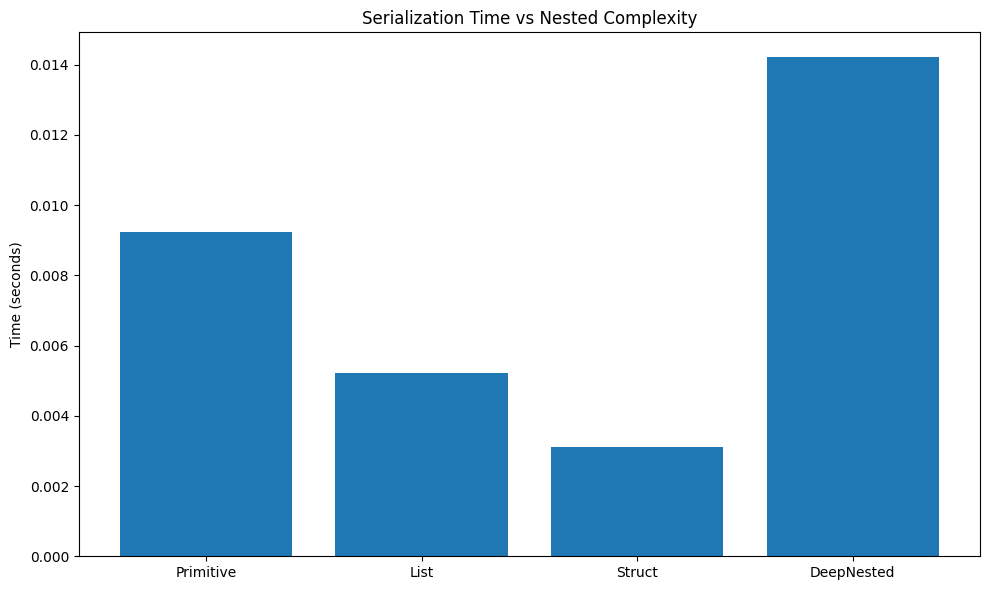

In [13]:
plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Structure"],
    results_df["Serialization_Time_s"]
)

plt.title(
    "Serialization Time vs Nested Complexity"
)

plt.ylabel("Time (seconds)")

plt.tight_layout()

plt.savefig(
    GRAPHS_DIR / "serialization_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

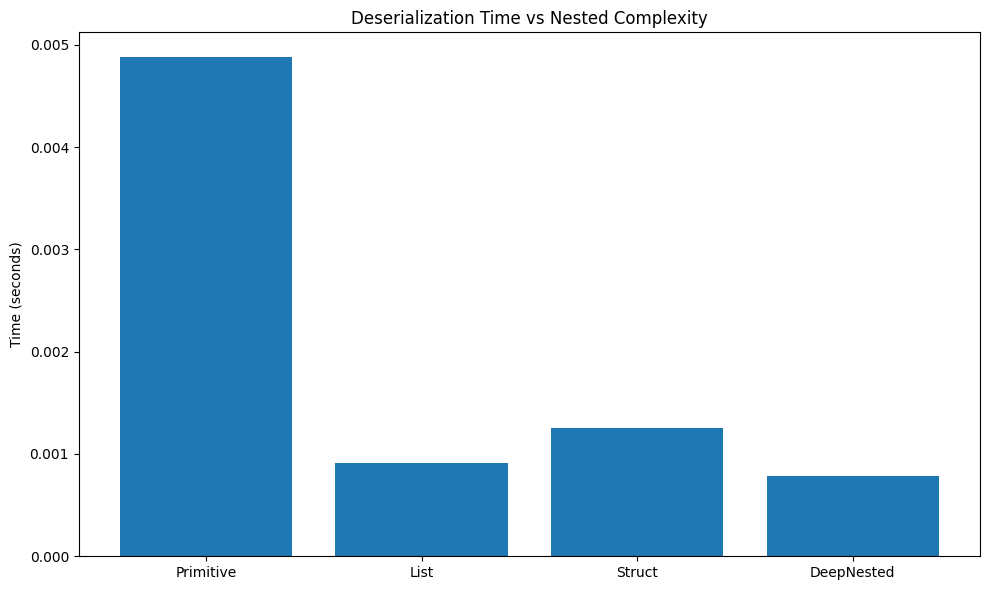

In [14]:
plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Structure"],
    results_df["Deserialization_Time_s"]
)

plt.title(
    "Deserialization Time vs Nested Complexity"
)

plt.ylabel("Time (seconds)")

plt.tight_layout()

plt.savefig(
    GRAPHS_DIR / "deserialization_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

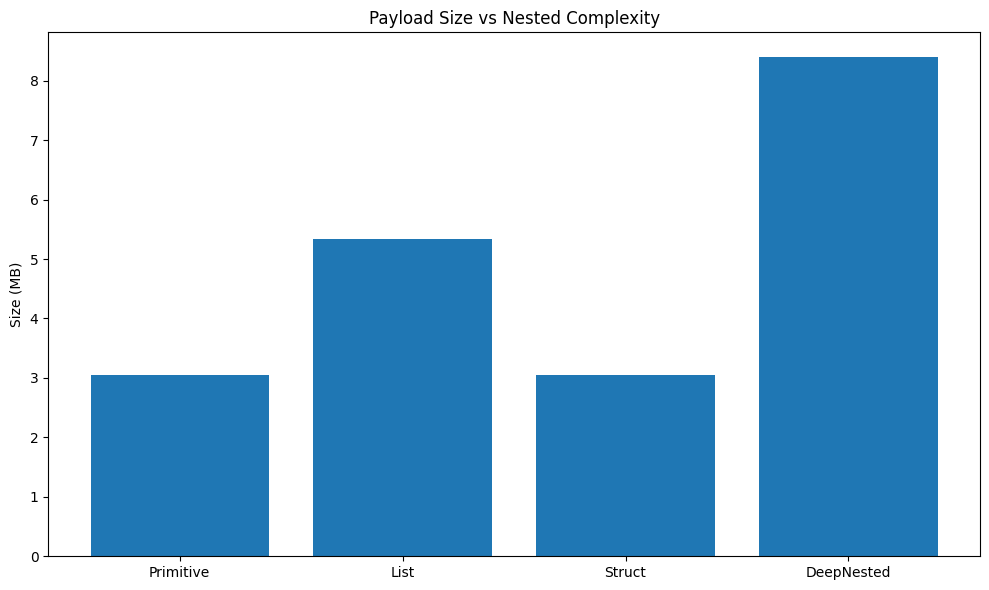

In [15]:
plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Structure"],
    results_df["Payload_Size_MB"]
)

plt.title(
    "Payload Size vs Nested Complexity"
)

plt.ylabel("Size (MB)")

plt.tight_layout()

plt.savefig(
    GRAPHS_DIR / "payload_size.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

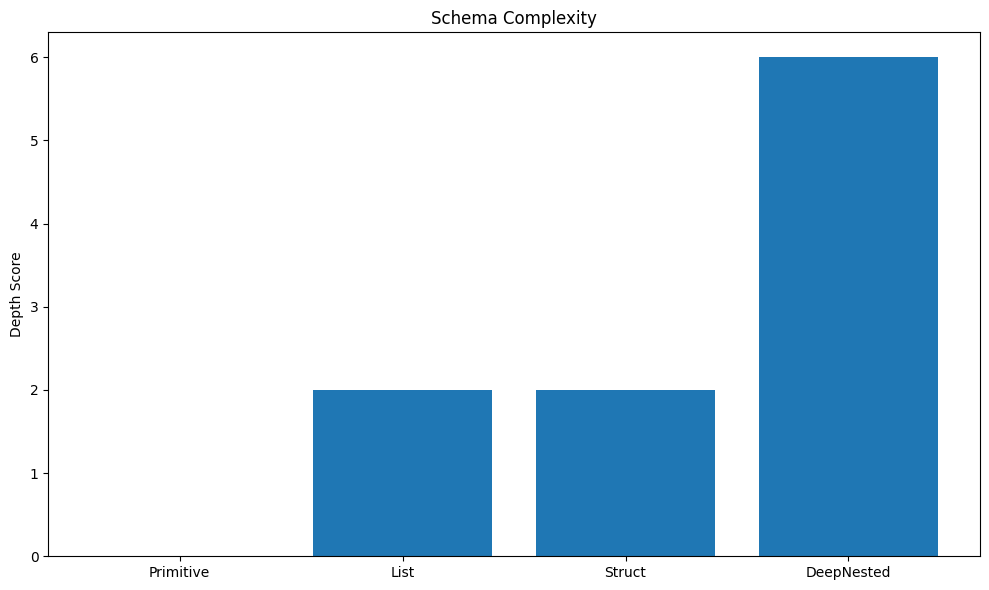

In [16]:
plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Structure"],
    results_df["Schema_Depth"]
)

plt.title(
    "Schema Complexity"
)

plt.ylabel("Depth Score")

plt.tight_layout()

plt.savefig(
    GRAPHS_DIR / "schema_depth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
csv_path = (
    TABLES_DIR /
    "nested_array_results.csv"
)

results_df.to_csv(
    csv_path,
    index=False
)

print(f"\nSaved CSV:\n{csv_path}")


Saved CSV:
/home/megh/arrow-ipc-analysis-linux/results/nested_array_effects/tables/nested_array_results.csv


In [18]:
summary_path = (
    LOGS_DIR /
    "summary.txt"
)

with open(summary_path, "w") as f:

    f.write("="*80 + "\n")
    f.write("NESTED ARRAY EFFECTS\n")
    f.write("="*80 + "\n\n")

    f.write(results_df.to_string())

print(f"\nSaved summary:\n{summary_path}")


Saved summary:
/home/megh/arrow-ipc-analysis-linux/results/nested_array_effects/logs/summary.txt
